In [2]:
!pip install infomap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 79.1 MB/s eta 0:00:00


In [3]:
from infomap import Infomap

In [4]:
from infomap import Infomap

im = Infomap()
print("Infomap installed successfully")

Infomap installed successfully


In [5]:
import networkx as nx
from infomap import Infomap

G = nx.karate_club_graph()  # small test graph

im = Infomap()

for u, v in G.edges():
    im.addLink(u, v)

im.run()

communities = {node.node_id: node.module_id for node in im.nodes}

print("Communities:", len(set(communities.values())))

Communities: 3


In [6]:
import networkx as nx
import numpy as np
from infomap import Infomap
from itertools import combinations


# -----------------------------------------
# STEP A : Set weights based on similarity
# -----------------------------------------
def set_edge_weights(G):
    """
    Assign weight based on similarity of node densities.
    weight = 1 / (1 + |density_i - density_j|)
    """

    for u, v in G.edges():
        di = G.nodes[u].get("density", 1)
        dj = G.nodes[v].get("density", 1)

        weight = 1 / (1 + abs(di - dj))
        G[u][v]["weight"] = weight

    return G


# -----------------------------------------
# STEP B : Run Infomap community detection
# -----------------------------------------
def run_infomap(G):

    im = Infomap("--two-level")

    for u, v, data in G.edges(data=True):
        w = data.get("weight", 1.0)
        im.addLink(u, v, w)

    im.run()

    clusters = {}

    for node in im.tree:
        if node.isLeaf:
            clusters[node.physicalId] = node.moduleIndex()

    return clusters


# -----------------------------------------
# Utility : Check connected subset
# -----------------------------------------
def connected_subset(G, subset):

    sub = G.subgraph(subset)
    return nx.is_connected(sub)


# -----------------------------------------
# Compute variance of density
# -----------------------------------------
def density_variance(G, nodes):

    vals = [G.nodes[n]["density"] for n in nodes]

    if len(vals) == 0:
        return float("inf")

    return np.var(vals)


# -----------------------------------------
# STEP C : refine cluster to reduce variance
# -----------------------------------------
def refine_cluster(G, nodes):

    best_subset = nodes
    best_var = density_variance(G, nodes)

    N = len(nodes)

    for k in range(N, 0, -1):

        for subset in combinations(nodes, k):

            if connected_subset(G, subset):

                var = density_variance(G, subset)

                if var < best_var:
                    best_var = var
                    best_subset = list(subset)

        if best_subset != nodes:
            break

    return best_subset


# -----------------------------------------
# Merge nodes in same cluster (coarse graining)
# -----------------------------------------
def merge_clusters(G, labels):

    newG = nx.Graph()

    cluster_nodes = {}

    for node, c in labels.items():
        cluster_nodes.setdefault(c, []).append(node)

    for c in cluster_nodes:
        newG.add_node(c)

    for u, v, data in G.edges(data=True):

        cu = labels[u]
        cv = labels[v]

        if cu != cv:

            w = data.get("weight", 1)

            if newG.has_edge(cu, cv):
                newG[cu][cv]["weight"] += w
            else:
                newG.add_edge(cu, cv, weight=w)

    return newG


# -----------------------------------------
# MAIN ALGORITHM
# -----------------------------------------
def community_detection_algorithm(G, max_iter=10):

    C = {node: node for node in G.nodes()}

    for z in range(max_iter):

        # Step A
        G = set_edge_weights(G)

        # Step B
        clusters = run_infomap(G)

        # Step C
        refined = {}

        for c in set(clusters.values()):

            nodes = [n for n in clusters if clusters[n] == c]

            best_subset = refine_cluster(G, nodes)

            for n in best_subset:
                refined[n] = c

        # merge clusters
        G = merge_clusters(G, refined)

        if len(G.nodes()) <= 1:
            break

    return refined

In [7]:
!pip install networkx python-louvain matplotlib

In [8]:
import networkx as nx
import matplotlib.pyplot as plt
import community.community_louvain as community_louvain

In [9]:
G = nx.karate_club_graph()

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())


Number of nodes: 34
Number of edges: 78


In [10]:
partition = community_louvain.best_partition(G)

num_communities = len(set(partition.values()))

print("Number of communities detected:", num_communities)

Number of communities detected: 4


In [11]:
modularity = community_louvain.modularity(partition, G)

print("Modularity score:", modularity)

Modularity score: 0.4438541256723074


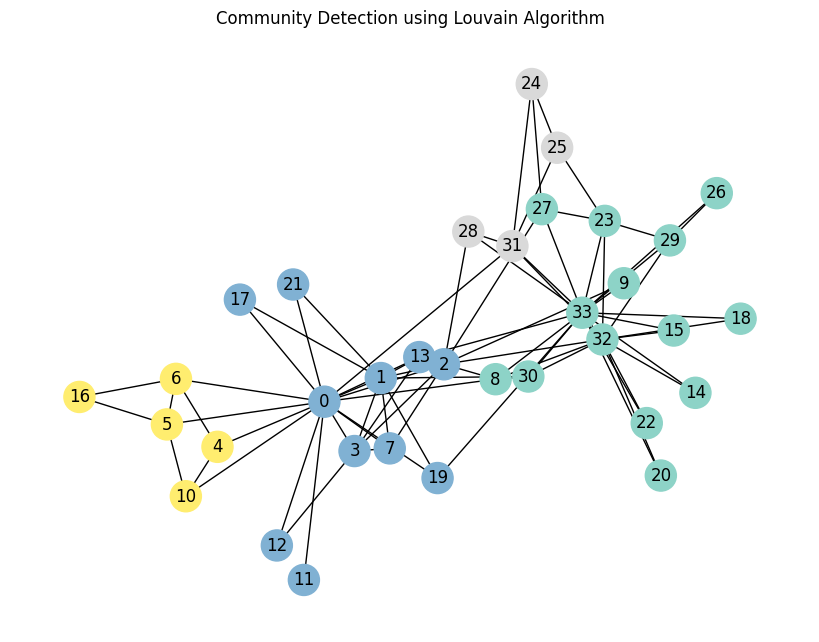

In [12]:
pos = nx.spring_layout(G)

colors = [partition[node] for node in G.nodes()]

plt.figure(figsize=(8,6))
nx.draw(G, pos, node_color=colors, with_labels=True, node_size=500, cmap=plt.cm.Set3)
plt.title("Community Detection using Louvain Algorithm")
plt.show()

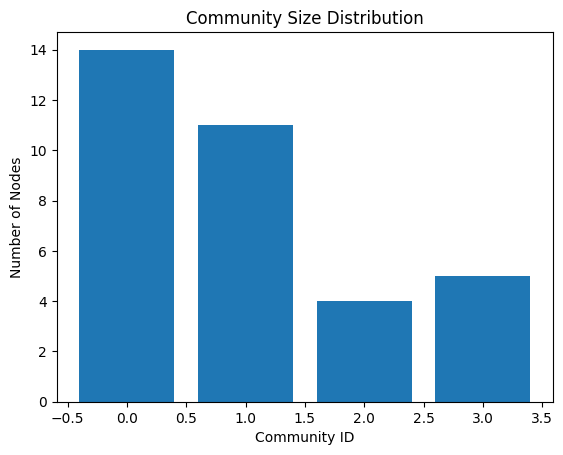

In [13]:
from collections import Counter

community_sizes = Counter(partition.values())

plt.bar(community_sizes.keys(), community_sizes.values())
plt.xlabel("Community ID")
plt.ylabel("Number of Nodes")
plt.title("Community Size Distribution")
plt.show()